In [ ]:
!pip install -U ultralytics
!pip uninstall clip -y
!pip install git+https://github.com/ultralytics/CLIP.git

In [67]:
import os
import cv2
import copy
import torch
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [68]:
image_dir = "/content/images"
segmentation_prompt = "a bean"

In [69]:
from ultralytics.models.sam import SAM3SemanticPredictor

# Initialize predictor with configuration
overrides = dict(
    conf=0.4, # 0.25
    task="segment",
    mode="predict",
    model="/content/drive/Shareddrives/Image analysis templates/sam3.pt",
    quantize='fp16',  # Use FP16 for faster inference
    save=False
)
predictor = SAM3SemanticPredictor(overrides=overrides)

WARNING ⚠️ imgsz=[640] must be multiple of max stride 14, updating to [644]

image 1/1 /content/images/IMG_0596.JPG: 644x644 49 a beans, 44.5ms
Speed: 4.0ms preprocess, 44.5ms inference, 23.5ms postprocess per image at shape (1, 3, 644, 644)


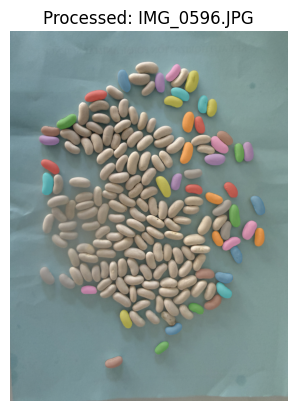

WARNING ⚠️ imgsz=[640] must be multiple of max stride 14, updating to [644]

image 1/1 /content/images/IMG_0595.JPG: 644x644 30 a beans, 43.1ms
Speed: 4.0ms preprocess, 43.1ms inference, 15.1ms postprocess per image at shape (1, 3, 644, 644)


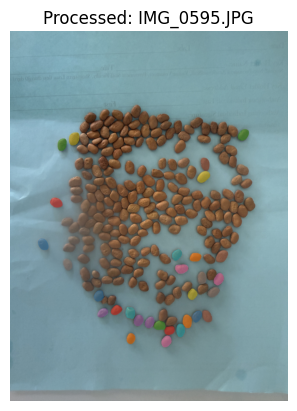

WARNING ⚠️ imgsz=[640] must be multiple of max stride 14, updating to [644]

image 1/1 /content/images/IMG_0594.JPG: 644x644 43 a beans, 43.5ms
Speed: 4.0ms preprocess, 43.5ms inference, 20.5ms postprocess per image at shape (1, 3, 644, 644)


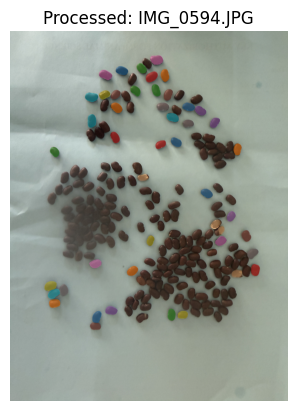

WARNING ⚠️ imgsz=[640] must be multiple of max stride 14, updating to [644]

image 1/1 /content/images/IMG_0593.JPG: 644x644 60 a beans, 43.5ms
Speed: 4.0ms preprocess, 43.5ms inference, 28.0ms postprocess per image at shape (1, 3, 644, 644)


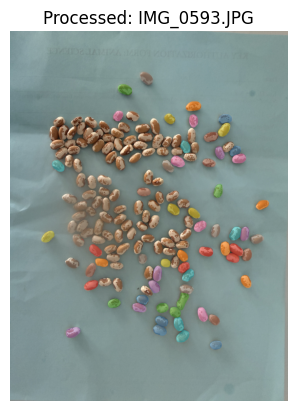

Analysis complete. Data saved to bean_analysis.csv


/usr/local/lib/python3.13/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,image,bean_id,width,height,ratio_h_w,mean_r,mean_g,mean_b,color_variance
0,IMG_0596.JPG,0,130.0,174.0,1.338867,172,159,136,24.439895
1,IMG_0596.JPG,1,78.0,158.0,2.025391,157,144,120,22.002710
2,IMG_0596.JPG,2,118.0,106.0,0.898438,174,166,154,28.552752
3,IMG_0596.JPG,3,116.0,134.0,1.155273,167,154,131,22.971190
4,IMG_0596.JPG,4,80.0,169.0,2.113281,174,159,134,31.571142


In [72]:
import os
import cv2
import copy
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd

# List to accumulate data for the CSV
bean_data = []

image_paths = os.listdir(image_dir)
for image_path in image_paths:
  predictor.set_image(os.path.join(image_dir, image_path))
  results = predictor(text=[segmentation_prompt])

  if results:
    first_result = results[0]
    orig_img = first_result.orig_img  # BGR format
    orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    h, w = first_result.orig_shape

    overlay_image = copy.deepcopy(orig_img).astype(np.float32)
    num_colors_to_use = 10
    colormap = plt.colormaps['tab10']
    colors_rgb_float = [colormap(i)[:3] for i in range(num_colors_to_use)]
    colors_bgr_uint8 = [(np.array(c) * 255).astype(np.uint8)[::-1] for c in colors_rgb_float]

    alpha = 0.5
    color_idx = 0

    for result in results:
        if result.masks is not None:
            # Bounding boxes in xywh format: [x_center, y_center, width, height]
            boxes = result.boxes.xywh.cpu().numpy()

            for i in range(result.masks.data.shape[0]):
                individual_mask_tensor = result.masks.data[i]
                mask_np = individual_mask_tensor.cpu().numpy().astype(bool)

                # 1. Calculate Ratio
                _, _, box_w, box_h = boxes[i]
                ratio = box_h / box_w if box_w != 0 else 0

                # 2. Calculate Mean RGB and Variance
                masked_pixels = orig_img_rgb[mask_np]
                if masked_pixels.size > 0:
                    # Round mean RGB to nearest whole number
                    mean_rgb = np.round(masked_pixels.mean(axis=0)).astype(int)
                    # Calculate standard deviation as a proxy for patternedness
                    # We take the mean of the standard deviations across the 3 channels
                    color_variance = np.mean(np.std(masked_pixels, axis=0))
                else:
                    mean_rgb = [0, 0, 0]
                    color_variance = 0

                # Append to list
                bean_data.append({
                    'image': image_path,
                    'bean_id': i,
                    'width': box_w,
                    'height': box_h,
                    'ratio_h_w': ratio,
                    'mean_r': mean_rgb[0],
                    'mean_g': mean_rgb[1],
                    'mean_b': mean_rgb[2],
                    'color_variance': color_variance
                })

                # Visualization overlay
                current_color_bgr = colors_bgr_uint8[color_idx % len(colors_bgr_uint8)]
                color_idx += 1
                color_float = np.array(current_color_bgr).astype(np.float32)
                overlay_image[mask_np] = (1 - alpha) * overlay_image[mask_np] + alpha * color_float

    # Display image progress
    plt.imshow(overlay_image.astype(np.uint8)[:,:,::-1])
    plt.title(f"Processed: {image_path}")
    plt.axis('off')
    plt.show()

# Create DataFrame and Save to CSV
df_beans = pd.DataFrame(bean_data)
df_beans.to_csv('bean_analysis.csv', index=False)
print("Analysis complete. Data saved to bean_analysis.csv")
display(df_beans.head())